In [1]:
# importo le librerie necessarie
from astroquery.jplhorizons import Horizons
import astropy.units as u
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# definisco il punto di osservazione
casa = {'lat': 41.114215,
        'lon': 16.873853,
        'elevation': 0.030,
        'body': '399'}

# dico a pandas di non andare a capo
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [3]:
# posizione di orion e della luna dal punto di osservazione
orion_home = Horizons(id='-1024', location=casa, epochs={'start':'2026-04-02 01:58:35', 'stop':'2026-04-11 00:00:42', 'step':'1min'})
moon_home = Horizons(id='301', location=casa, epochs={'start':'2026-04-02 01:58:35', 'stop':'2026-04-11 00:00:42', 'step':'1min'})
table_orion_home = orion_home.ephemerides().to_pandas()
table_moon_home = moon_home.ephemerides().to_pandas()

table_orion_home = table_orion_home[['datetime_str', 'AZ', 'EL', 'delta', 'delta_rate']]
table_orion_home['delta'] = [(el * u.au).to(u.km).value for el in table_orion_home['delta']]
table_orion_home['datetime_str'] = pd.to_datetime(table_orion_home['datetime_str']).dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')
# calcolo l'effetto doppler sulla frequenza
table_orion_home['f_rx'] = 1000 * 2216.5 * (1 - table_orion_home['delta_rate'] / 299792.458)
# calcolo quando orion è sopra l'orizzonte
table_orion_home['visible'] = ['vis' if el >= 0 else 'inv' for el in table_orion_home['EL']]

table_moon_home = table_moon_home[['datetime_str', 'AZ', 'EL', 'delta']]
table_moon_home['delta'] = [(el * u.au).to(u.km).value for el in table_moon_home['delta']]
table_moon_home['datetime_str'] = pd.to_datetime(table_moon_home['datetime_str']).dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')

In [4]:
# distanza di orion e della luna dalla terra
orion = Horizons(id='-1024', location='500@399', epochs={'start':'2026-04-02 01:58:35', 'stop':'2026-04-11 00:00:42', 'step':'1min'})
moon = Horizons(id='301', location='500@399', epochs={'start':'2026-04-02 01:58:35', 'stop':'2026-04-11 00:00:42', 'step':'1min'})
table_orion = orion.ephemerides().to_pandas()
table_moon = moon.ephemerides().to_pandas()

table_orion = table_orion[['datetime_str', 'delta']]
table_orion['delta'] = [(el * u.au).to(u.km).value - 6372.797 for el in table_orion['delta']]
table_orion['datetime_str'] = pd.to_datetime(table_orion['datetime_str']).dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')

table_moon = table_moon[['datetime_str', 'delta']]
table_moon['delta'] = [(el * u.au).to(u.km).value - 6372.797 for el in table_moon['delta']]
table_moon['datetime_str'] = pd.to_datetime(table_moon['datetime_str']).dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')

# unisco le tabelle
table_orion = table_orion.merge(table_orion_home, on="datetime_str")
# differenza tra la distanza di orion e quella della luna
table_orion['difference'] = table_orion['delta_x'] - table_moon['delta']

/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/2205042649.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10'),
 Text(20553.916666666668, 0, '2026-04-11')]

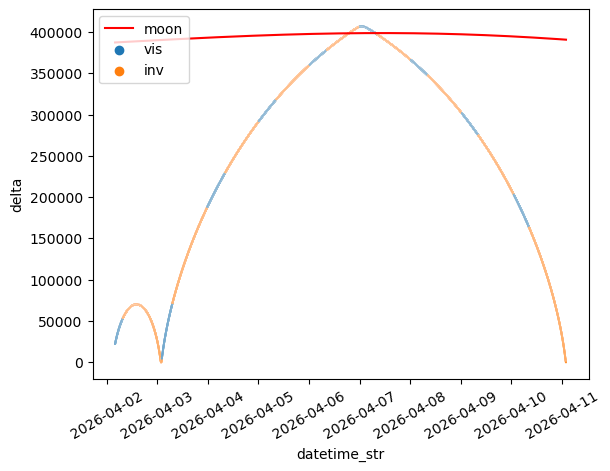

In [5]:
# grafico della distanza di orion (in blu quando sopra l'orizzonte) e della luna dalla terra
fig, ax_left = plt.subplots()
first_plot = sns.lineplot(table_moon, x='datetime_str', y='delta', label='moon', color="red")
sns.scatterplot(table_orion, x='datetime_str', y='delta_x', s=2, hue=table_orion['visible'])
plt.legend()
ax_left.legend(loc='upper left')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/3061207098.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10'),
 Text(20553.916666666668, 0, '2026-04-11')]

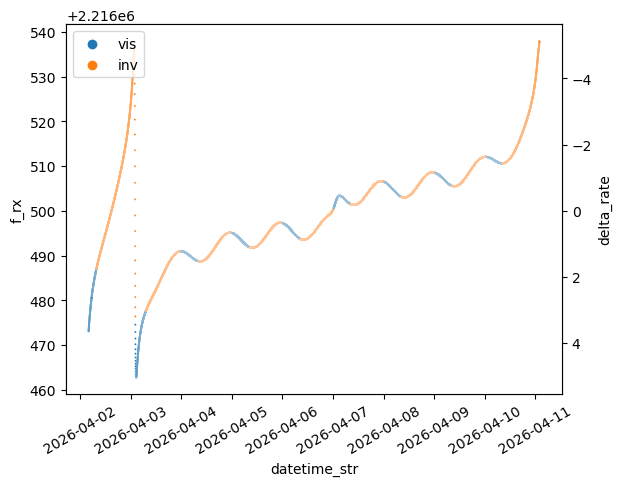

In [6]:
# grafico della frequenza (a sinistra) e della velocità in km/s (a destra) di orion
fig, ax_left = plt.subplots()
ax_right = plt.twinx()
first_plot = sns.scatterplot(table_orion, x='datetime_str', y='f_rx', s=2, hue=table_orion['visible'], ax=ax_left)
sns.scatterplot(table_orion, x='datetime_str', y='delta_rate', ax=ax_right, s=2, color="green")
plt.legend()
ax_right.invert_yaxis()
ax_left.legend(loc='upper left')
ax_left.set_zorder(ax_right.get_zorder() + 1)
ax_left.patch.set_visible(True)
ax_right.legend(loc='upper right')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)
# la deviazione doppler massima è di +- 38 khz, quella media di +- 10 khz

In [7]:
# calcolo apogei e perigei locali di orion
rolling_win = table_orion['delta_x'].rolling(window=3, center=True)
rolling_min = rolling_win.min()
rolling_max = rolling_win.max()
is_minimo = table_orion['delta_x'] == rolling_min
is_minimo = is_minimo & rolling_min.notna()
print(table_orion[is_minimo])
is_massimo = table_orion['delta_x'] == rolling_max
is_massimo = is_massimo & rolling_max.notna()
print(table_orion[is_massimo])
# la prima orbita è fortemente ellittica (196 x 70158 km), poi è previsto un sorvolo della luna con distanza massima di 406778 km dalla terra (record)

                  datetime_str     delta_x          AZ         EL      delta_y  delta_rate          f_rx visible     difference
1311 2026-04-03 01:49:35+02:00  196.005546  317.985191 -48.185945  9778.808331   -4.500125  2.216533e+06     inv -389993.693288
                  datetime_str        delta_x          AZ         EL        delta_y  delta_rate          f_rx visible     difference
609  2026-04-02 14:07:35+02:00   70157.902312  274.917652 -53.044193   81525.138934    0.177346  2.216499e+06     inv -318445.675303
7029 2026-04-07 01:07:35+02:00  406777.685267  136.325846   6.396357  412377.119322   -0.243375  2.216502e+06     vis    8299.338380


In [8]:
# calcolo i passaggi visibili dal punto di osservazione
transizioni = table_orion['visible'].map({'vis': 1, 'inv': 0}).diff()
inizi = table_orion[transizioni == 1].index
fini = table_orion[transizioni == -1].index
# Se il dataframe inizia già con vis=vis, il primo passaggio parte dall'inizio
if table_orion['visible'].iloc[0] == 'vis':
    inizi = inizi.insert(0, table_orion.index[0])
# Se il dataframe finisce con vis=inv, l'ultimo passaggio arriva fino alla fine
if table_orion['visible'].iloc[-1] == 'vis':
    fini = fini.append(pd.Index([table_orion.index[-1]]))

passaggi_list = []
for i_start, i_end in zip(inizi, fini):
    finestra = table_orion.loc[i_start:i_end]
    idx_max = finestra['EL'].idxmax()
    passaggi_list.append({
        'inizio': table_orion.loc[i_start, 'datetime_str'],
        'fine': table_orion.loc[i_end, 'datetime_str'],
        'max_el_time': table_orion.loc[idx_max, 'datetime_str'],
        'max_el': table_orion.loc[idx_max, 'EL'],
        'max_el_az': table_orion.loc[idx_max, 'AZ'],
        'max_el_dist': table_orion.loc[idx_max, 'delta_y']
    })
passaggi = pd.DataFrame(passaggi_list)
print(passaggi)
# i passaggi sono nove e sono abbastanza bassi sull'orizzonte (20 gradi al massimo, a sud)

                     inizio                      fine               max_el_time     max_el   max_el_az    max_el_dist
0 2026-04-02 03:58:35+02:00 2026-04-02 07:41:35+02:00 2026-04-02 03:58:35+02:00  16.106269  212.263947   26168.176249
1 2026-04-03 02:10:35+02:00 2026-04-03 07:13:35+02:00 2026-04-03 03:09:35+02:00  20.338366  210.418550   25817.948360
2 2026-04-03 23:49:35+02:00 2026-04-04 08:20:35+02:00 2026-04-04 04:04:35+02:00  21.679163  179.780427  214049.467024
3 2026-04-05 00:13:35+02:00 2026-04-05 08:34:35+02:00 2026-04-05 04:23:35+02:00  21.150435  179.970935  309671.796350
4 2026-04-06 00:23:35+02:00 2026-04-06 08:39:35+02:00 2026-04-06 04:31:35+02:00  20.887220  180.002157  373764.680461
5 2026-04-07 00:22:35+02:00 2026-04-07 08:32:35+02:00 2026-04-07 04:25:35+02:00  20.797254  179.786719  407513.943418
6 2026-04-08 00:24:35+02:00 2026-04-08 08:28:35+02:00 2026-04-08 04:26:35+02:00  19.713604  179.837838  360885.343185
7 2026-04-09 00:40:35+02:00 2026-04-09 08:28:35+02:00 20

/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/230355297.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10')]

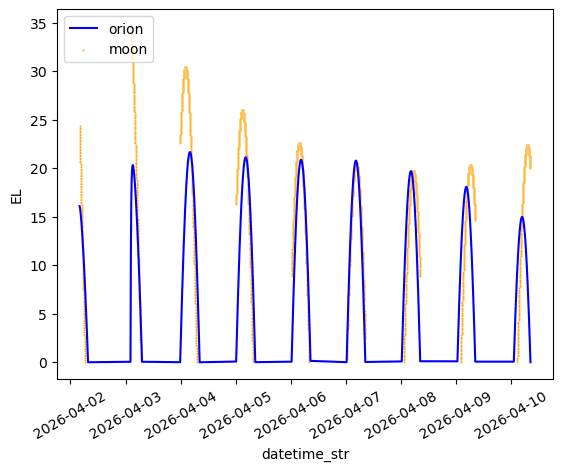

In [9]:
# grafico dell'elevazione di orion (solo quando è sopra l'orizzonte) e della luna
table_moon_home = table_moon_home[table_orion_home['EL'] >= 0]
table_moon_home = table_moon_home[table_moon_home['EL'] >= 0]
table_orion_home = table_orion_home[table_orion_home['EL'] >= 0]
fig, ax_left = plt.subplots()
first_plot = sns.lineplot(table_orion_home, x='datetime_str', y='EL', label='orion', color='blue')
sns.scatterplot(table_moon_home, x='datetime_str', y='EL', label='moon', s=2, color='orange')
plt.legend()
ax_left.legend(loc='upper left')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)

/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/1569417691.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10')]

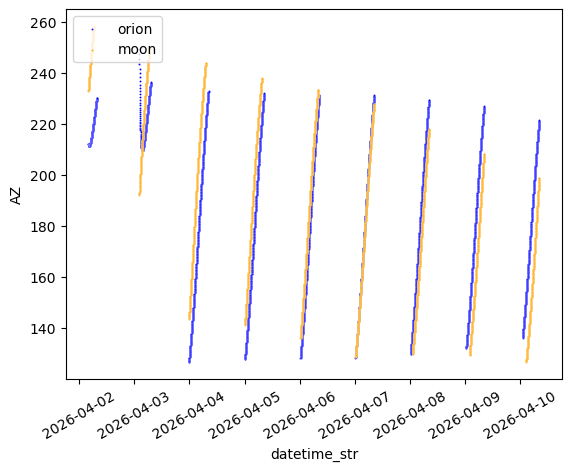

In [10]:
# grafico dell'azimuth di orion (solo quando è sopra l'orizzonte) e della luna
fig, ax_left = plt.subplots()
first_plot = sns.scatterplot(table_orion_home, x='datetime_str', y='AZ', label='orion', s=2, color='blue')
sns.scatterplot(table_moon_home, x='datetime_str', y='AZ', label='moon', s=2, color='orange')
plt.legend()
ax_left.legend(loc='upper left')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)
# sorge sempre a sudest (13 gradi) e tramonta sempre a sudovest (230 gradi)

In [11]:
# calcolo la distanza di orion dalla luna
dist = Horizons(id='-1024', location='500@301', epochs={'start':'2026-04-02 01:58:35', 'stop':'2026-04-11 00:00:42', 'step':'5min'})
table_dist = dist.ephemerides().to_pandas()
table_dist = table_dist[['datetime_str', 'delta']]
table_dist['delta'] = [(el * u.au).to(u.km).value - 3476 for el in table_dist['delta']]
table_dist['datetime_str'] = pd.to_datetime(table_dist['datetime_str']).dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')

#calcolo velocità e accelerazione di orion rispetto alla luna
table_dist['diff']=table_dist['delta'] -table_dist['delta'].shift(1)
table_dist['acc']=table_dist['diff'] -table_dist['diff'].shift(1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/3756946834.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10'),
 Text(20553.916666666668, 0, '2026-04-11')]

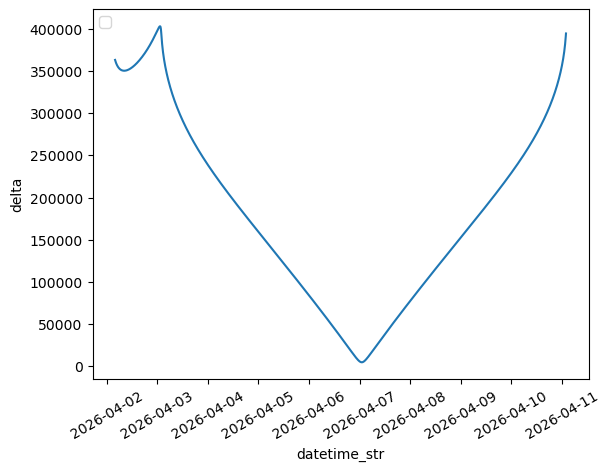

In [12]:
# grafico della distanza di orion dalla luna
fig, ax_left = plt.subplots()
first_plot = sns.lineplot(table_dist, x='datetime_str', y='delta')
plt.legend()
ax_left.legend(loc='upper left')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/3067983601.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10'),
 Text(20553.916666666668, 0, '2026-04-11')]

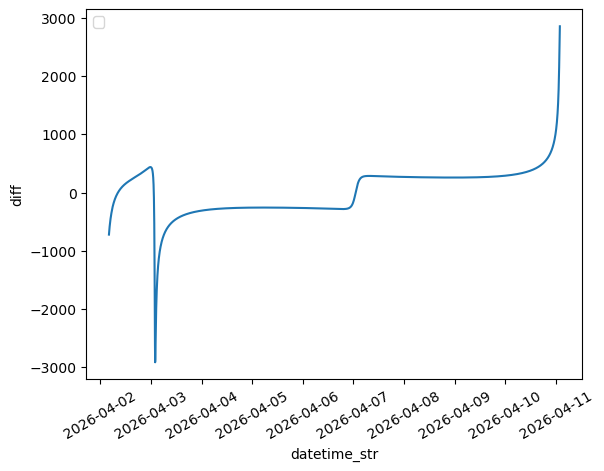

In [13]:
# grafico della velocità di orion rispetto alla luna
fig, ax_left = plt.subplots()
first_plot = sns.lineplot(table_dist, x='datetime_str', y='diff')
plt.legend()
ax_left.legend(loc='upper left')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/3643420173.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20544.916666666668, 0, '2026-04-02'),
 Text(20545.916666666668, 0, '2026-04-03'),
 Text(20546.916666666668, 0, '2026-04-04'),
 Text(20547.916666666668, 0, '2026-04-05'),
 Text(20548.916666666668, 0, '2026-04-06'),
 Text(20549.916666666668, 0, '2026-04-07'),
 Text(20550.916666666668, 0, '2026-04-08'),
 Text(20551.916666666668, 0, '2026-04-09'),
 Text(20552.916666666668, 0, '2026-04-10'),
 Text(20553.916666666668, 0, '2026-04-11')]

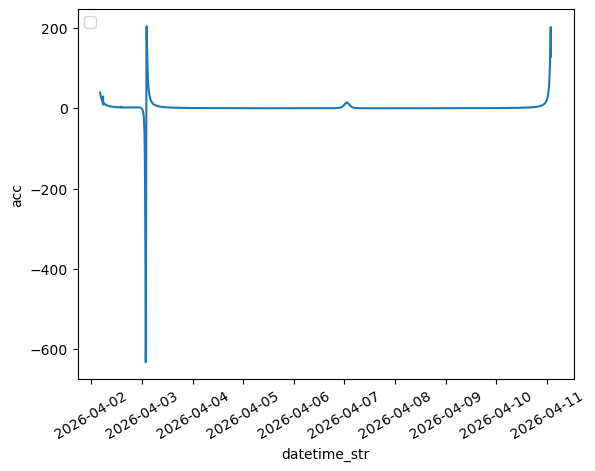

In [14]:
# grafico dell'accelerazione di orion rispetto alla luna
fig, ax_left = plt.subplots()
first_plot = sns.lineplot(table_dist, x='datetime_str', y='acc')
plt.legend()
ax_left.legend(loc='upper left')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)
# si può vedere bene l'accensione dei motori per il tle alla mezzanotte del 3 e lo splashdown l'11

/var/folders/72/84fp7phs75zft9q6bydgrjg40000gn/T/ipykernel_9549/3386348228.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)


[Text(20549.916666666668, 0, '04-07 00'),
 Text(20549.958333333332, 0, '04-07 01'),
 Text(20550.0, 0, '04-07 02'),
 Text(20550.041666666668, 0, '04-07 03'),
 Text(20550.083333333332, 0, '04-07 04'),
 Text(20550.125, 0, '04-07 05'),
 Text(20550.166666666668, 0, '04-07 06'),
 Text(20550.208333333332, 0, '04-07 07'),
 Text(20550.25, 0, '04-07 08')]

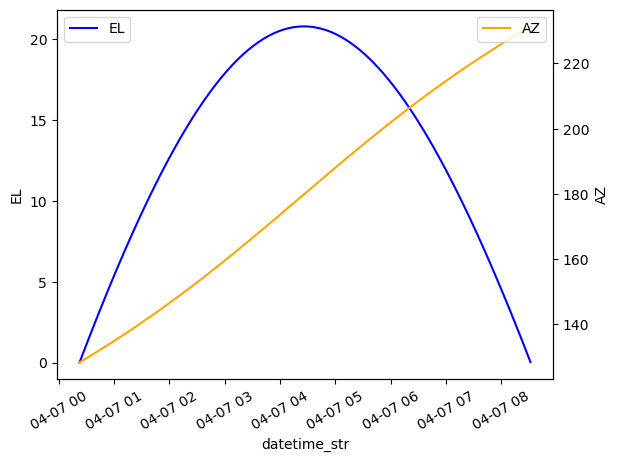

In [15]:
# grafico di elevazione e azimuth di orion al passaggio dietro la luna
table_orion_pass = table_orion[(table_orion['datetime_str'] >= '2026-04-07 00:22:00') & (table_orion['datetime_str'] <= '2026-04-07 08:32:00')]
fig, ax_left = plt.subplots()
ax_right = plt.twinx()
first_plot = sns.lineplot(table_orion_pass, x='datetime_str', y='EL', label='EL', color='blue', ax=ax_left)
sns.lineplot(table_orion_pass, x='datetime_str', y='AZ', label='AZ', color='orange', ax=ax_right)
plt.legend()
ax_left.legend(loc='upper left')
ax_right.legend(loc='upper right')
first_plot.set_xticklabels(first_plot.get_xticklabels(), rotation=30)

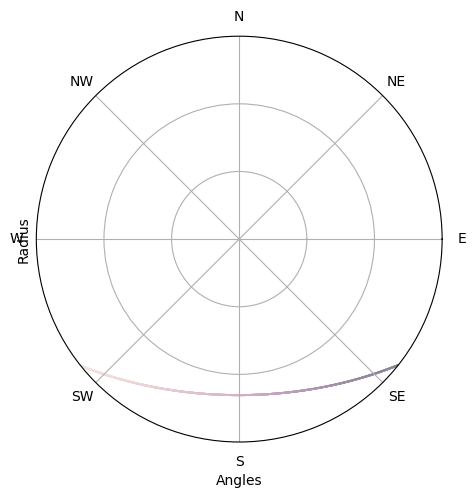

In [16]:
# ottengo elevazione e azimuth ogni dieci secondi, per il tracciamento
start = table_orion_pass['datetime_str'].min().tz_convert('UTC').tz_localize(None) - pd.Timedelta(minutes=1)
stop = table_orion_pass['datetime_str'].max().tz_convert('UTC').tz_localize(None) + pd.Timedelta(minutes=1)
steps = (len(table_orion_pass) + 1) * 60
n_seconds = 10

obj = Horizons(id='-1024', location=casa, epochs={'start':str(start), 'stop':str(stop), 'step':str(int(steps/n_seconds))})
table = obj.ephemerides().to_pandas()
table = table[['datetime_str', 'AZ', 'EL', 'delta']]
table['delta'] = [(el * u.au).to(u.km).value for el in table['delta']]
table['datetime_str'] = pd.to_datetime(table['datetime_str']).dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')
table = table[table['EL'] > 0]

d = {'Angles': table['AZ'], 'Radius': table['EL']}
df = pd.DataFrame(data=d)
df['Angles'] = -(df['Angles']-90)*np.pi/180
df['Radius'] = 90 - df['Radius']

g = sns.FacetGrid(df, subplot_kws=dict(projection='polar'), height=5, sharex=False, sharey=False, despine=False)
g.map_dataframe(sns.scatterplot, x='Angles', y='Radius', hue=table['delta'], s=2)
g.ax.set_rmax(90)
g.ax.set_rticks([30, 60])
g.set_yticklabels(['', ''])
g.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])
g.ax.grid(True)
plt.show()

In [17]:
# importo le librerie per il motore
import socket
from datetime import datetime
import pytz
from time import sleep

In [18]:
# classe per il controllo del rotore
class Rotor:
    __rotctl = None

    def __init__(self):
        try:
            self.__rotctl = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            self.__rotctl.connect(('localhost', 4533))
        except Exception as e:
            print("Failed to connect to rotctld on localhost:4533: " + str(e))
            exit(1)

    def send_azel_command(self, azimuth, elevation):
        if self.__rotctl:
            self.__rotctl.send(("+P " + str(azimuth) + " " + str(elevation) + "\n").encode('ascii'))
            return self.__rotctl.recv(4096).decode('ascii')
        return None

    def send_get_command(self):
        if self.__rotctl:
            self.__rotctl.send(("p\n").encode('ascii'))
            ret = self.__rotctl.recv(4096).decode('ascii').splitlines()
            return float(ret[0]), float(ret[1])
        return None

    def send_stop_command(self):
        if self.__rotctl:
            self.__rotctl.send(("+S\n").encode('ascii'))
            return self.__rotctl.recv(4096).decode('ascii')
        return None

    def close(self):
        if self.__rotctl:
            self.__rotctl.close()

rotor = Rotor()
#rotctld -vvvvv -m 2401 -r COM1

Failed to connect to rotctld on localhost:4533: [Errno 61] Connection refused


In [19]:
# traccio orion
while True:
    now = datetime.now(pytz.timezone('Europe/Rome')).strftime('%Y-%m-%d %H:%M:%S%z')
    next_position = table[table["datetime_str"] >= now]
    if len(next_position) > 0:
        ret = rotor.send_azel_command(next_position.iloc[0]["AZ"], next_position.iloc[0]["EL"])
        #print(ret)
        sleep(10)
    else:
        sleep(5)
        rotor.close()
        break

BrokenPipeError: [Errno 32] Broken pipe